In [66]:
import kagglehub
ankurzing_sentiment_analysis_for_financialnews_path = kagglehub.dataset_download('ankurzing/sentiment-analysis-for-financial-news')

print(f'Data source import complete at {ankurzing_sentiment_analysis_for_financialnews_path}')

Data source import complete at /kaggle/input/datasets/ankurzing/sentiment-analysis-for-financial-news


In [67]:
import pandas as pd
import os

def load_and_unify_fintech_data():
    # 1. Define the correct path for Kaggle
    # The directory structure usually follows: /kaggle/input/[dataset-name]/[filename]
    file_path = '/kaggle/input/datasets/ankurzing/sentiment-analysis-for-financial-news/all-data.csv'
    
    # Safety check: List files if you are unsure of the exact name
    # print(os.listdir('/kaggle/input/sentiment-analysis-for-financial-news/'))

    # 2. Read the data directly from the input folder
    # Financial PhraseBank uses 'latin-1' encoding
    df_jargon = pd.read_csv(file_path, encoding='latin-1', header=None, names=['sentiment', 'text'])
    
    # 3. Map sentiments to numerical labels
    df_jargon['label'] = df_jargon['sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})
    
    # 4. Clean and Shuffle
    # We drop any rows that failed to map (NaN) and shuffle the dataset
    df_jargon = df_jargon[['text', 'label']].dropna()
    combined_df = df_jargon.sample(frac=1, random_state=42).reset_index(drop=True)
    
    return combined_df

# Execute
df = load_and_unify_fintech_data()
print(f"Total Unified Records: {len(df)}")
print(df.head(50))

Total Unified Records: 4846
                                                 text  label
0   The company was supposed to deliver machinery ...      1
1   UNC Charlotte would also deploy SSH Tectia Con...      1
2   In 2009 , Lee & Man had a combined annual prod...      1
3   `` That 's a very high figure on the European ...      1
4   In Finland , the corresponding service is Alma...      1
5   Construction is scheduled to start in April-Ju...      1
6   Finnish-owned contract manufacturer of electro...      2
7   The gross area of the Innova 2 project will be...      1
8   Finnish home decoration and arts and crafts re...      1
9   Deliveries will start in the second half of 20...      1
10  Steek , which was set up in 2002 , is based in...      1
11  Outotec said it won new orders worth 492.9 mln...      2
12  The store is located in Poznan in a shopping c...      1
13             The value of the order is USD 2.2 mn .      1
14  The company expects meat purchases to remain a...    

In [68]:
import re

def clean_and_normalize(text):
  """1. Data Cleaning and Normalization"""
  text = text.lower()
  # # Map Emojis before removing symbols
  # for emoji, word in self.emoji_map.items():
  #     text = text.replace(emoji, f" {word} ")

  # Remove URLs and extra symbols, but keep % and $ for context
  text = re.sub(r'http\S+|www\S+', '', text)
  text = re.sub(r'[^a-zA-Z0-9\s%$]', '', text)
  return " ".join(text.split())

df['text'] = df['text'].apply(clean_and_normalize)
print(df.head(50))

                                                 text  label
0   the company was supposed to deliver machinery ...      1
1   unc charlotte would also deploy ssh tectia con...      1
2   in 2009 lee man had a combined annual producti...      1
3   that s a very high figure on the european scal...      1
4   in finland the corresponding service is alma m...      1
5   construction is scheduled to start in apriljun...      1
6   finnishowned contract manufacturer of electron...      2
7   the gross area of the innova 2 project will be...      1
8   finnish home decoration and arts and crafts re...      1
9   deliveries will start in the second half of 20...      1
10  steek which was set up in 2002 is based in bor...      1
11  outotec said it won new orders worth 4929 mln ...      2
12  the store is located in poznan in a shopping c...      1
13                the value of the order is usd 22 mn      1
14  the company expects meat purchases to remain a...      1
15  finnish house manufa

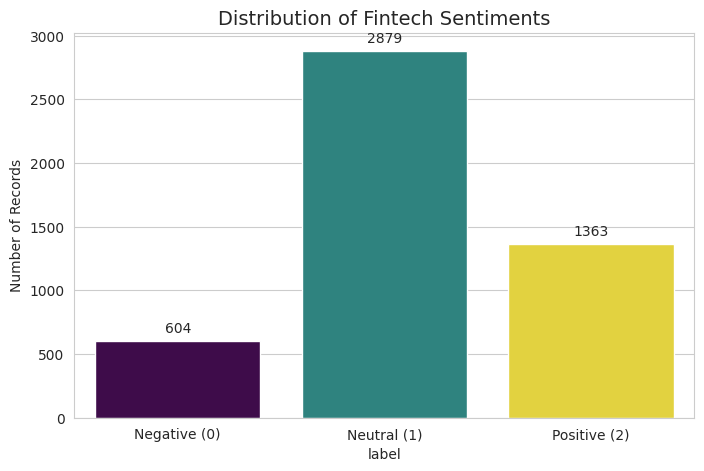

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# 1. FIX: Assign 'x' to 'hue' and set 'legend=False' to satisfy new Seaborn requirements
ax = sns.countplot(x='label', data=df, hue='label', palette="viridis", legend=False)

# 2. FIX: Set ticks explicitly before setting labels to avoid the FixedLocator warning
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Negative (0)', 'Neutral (1)', 'Positive (2)'])

plt.title("Distribution of Fintech Sentiments", fontsize=14)
plt.ylabel("Number of Records")

# Add count labels on top of each bar
for p in ax.patches:
    if p.get_height() > 0: # Ensure we only label bars that exist
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')

plt.show()

In [70]:
import pandas as pd

def get_balanced_subset(df, total_samples=1000):
    # Calculate samples needed per class
    n_per_class = total_samples // 3 
    
    # Create subsets for each label
    neg_df = df[df['label'] == 0]
    neu_df = df[df['label'] == 1]
    pos_df = df[df['label'] == 2]
    
    # Randomly sample from each
    # .sample(n) picks exactly 'n' records
    neg_sample = neg_df.sample(n=n_per_class, random_state=42)
    neu_sample = neu_df.sample(n=n_per_class, random_state=42)
    pos_sample = pos_df.sample(n=n_per_class, random_state=42)
    
    # Combine and shuffle
    balanced_df = pd.concat([neg_sample, neu_sample, pos_sample])
    return balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 1. Create the balanced 1000-row dataframe
df_balanced = get_balanced_subset(df, total_samples=1000)

print("New Class Distribution:")
print(df_balanced['label'].value_counts())

New Class Distribution:
label
1    333
2    333
0    333
Name: count, dtype: int64


In [71]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# Split into Train, Validation, and Test
# First, split into training (80%) and temporary (20% for test)
train_val_df, test_df = train_test_split(df_balanced, test_size=0.2, random_state=42, stratify=df_balanced['label'])

# Then, split the training_val_df into actual training (80% of remaining) and validation (20% of remaining)
train_df, val_df = train_test_split(train_val_df, test_size=0.25, random_state=42, stratify=train_val_df['label']) # 0.25 * 0.8 = 0.2, so 20% for validation

# Convert to Hugging Face Dataset format
ds_train = Dataset.from_pandas(train_df[['text', 'label']])
ds_val = Dataset.from_pandas(val_df[['text', 'label']])
ds_test = Dataset.from_pandas(test_df[['text', 'label']])

print(f"Total samples after sampling: {len(df_balanced)}")
print(f"Training samples: {len(ds_train)}")
print(f"Validation samples: {len(ds_val)}")
print(f"Test samples: {len(ds_test)}")


Total samples after sampling: 999
Training samples: 599
Validation samples: 200
Test samples: 200


In [72]:
import torch
from torch import nn
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Define weights: [Negative: 2.0, Neutral: 1.0, Positive: 1.0]
        # This forces the model to prioritize getting Negatives (and Sarcasm) right.
        weights = torch.tensor([2.0, 1.0, 1.0]).to(logits.device)
        loss_fct = nn.CrossEntropyLoss(weight=weights)

        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [73]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Define the Model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# 1. Check for GPU (CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Move your model to the GPU
model.to(device)

# Add your jargon as dedicated tokens
special_tokens_dict = {'additional_special_tokens': ['kyc', 'apr', 'overdraft', 'low_apr', 'under_apr', 'fast_kyc']}
num_added_toks = tokenizer.add_special_tokens(special_tokens_dict)
model.resize_token_embeddings(len(tokenizer))

# After resizing, you can optionally initialize new weights to the mean of existing ones
with torch.no_grad():
    embeddings = model.get_input_embeddings()
    # Average of all existing embeddings
    mean_embedding = embeddings.weight[:-num_added_toks].mean(dim=0)
    # Set new tokens to this mean
    for i in range(num_added_toks):
        embeddings.weight[-1-i] = mean_embedding

def preprocess(examples):
    return tokenizer(examples["text"], return_tensors="pt", truncation=True, padding=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_tokenized = ds_train.map(preprocess, batched=True)
val_tokenized = ds_val.map(preprocess, batched=True)

# Metrics Function
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

# Training Arguments
args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    fp16=True,                # Use Mixed Precision (faster on GPU)
    use_cpu=False,            # Ensure CPU is NOT used
    per_device_train_batch_size=10,
    num_train_epochs=15,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_steps=5
)

# trainer = Trainer(
#     model=model,
#     args=args,
#     train_dataset=train_tokenized,
#     eval_dataset=val_tokenized,
#     data_collator=data_collator,
#     compute_metrics=compute_metrics
# )
trainer = WeightedTrainer(
    model=model,
    args=args, # Use your previous TrainingArguments
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda


Map:   0%|          | 0/599 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.784322,0.785147,0.525000,0.480914
2,0.578842,0.508408,0.795000,0.790467
3,0.448186,0.408879,0.805000,0.803167
4,0.266905,0.374406,0.835000,0.831887
5,0.219588,0.378135,0.825000,0.823407
6,0.091490,0.402230,0.825000,0.823622
7,0.116613,0.480367,0.830000,0.832095
8,0.046092,0.454337,0.830000,0.828173
9,0.017964,0.483422,0.835000,0.834510
10,0.013785,0.519018,0.820000,0.820336


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=450, training_loss=0.19394260081979964, metrics={'train_runtime': 69.7064, 'train_samples_per_second': 128.898, 'train_steps_per_second': 6.456, 'total_flos': 176676369165720.0, 'train_loss': 0.19394260081979964, 'epoch': 15.0})

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


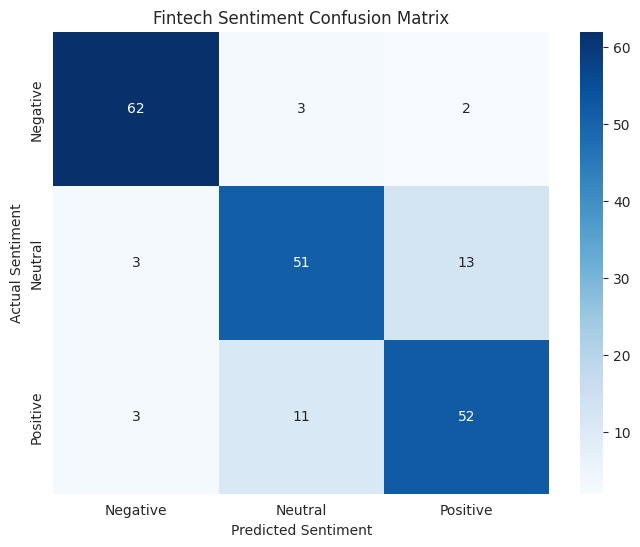

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Get predictions on your test set
predictions = trainer.predict(val_tokenized)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# 2. Compute the matrix
cm = confusion_matrix(y_true, y_pred)
labels = ['Negative', 'Neutral', 'Positive']

# 3. Plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Fintech Sentiment Confusion Matrix')
plt.show()

In [79]:
import torch

def predict(text):
    # 1. Ensure the model is on the correct device (GPU if available)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # print(f"Using device: {device}")
    model.to(device)
    model.eval() # Set to evaluation mode

    # 2. Preprocess and Tokenize
    # Ensure this matches the tokenizer you used during training
    inputs = tokenizer(
        text, 
        return_tensors="pt", 
        truncation=True, 
        padding=True
    ).to(device)

    # 3. Inference
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
    
    # 4. Map ID to Label String
    # 0: negative, 1: neutral, 2: positive
    prediction_id = torch.argmax(logits, dim=-1).item()
    label_map = {0: "negative", 1: "neutral", 2: "positive"}
    
    return label_map[prediction_id]

In [80]:
import torch
# Take 10 samples from validation
for i in range(10):
    text = ds_test[i]['text']
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        logits = model(**inputs).logits
    print(f"Logits: {logits.cpu().numpy()} | Pred: {torch.argmax(logits).item()}")

Logits: [[-1.2191713  4.009821  -1.762999 ]] | Pred: 1
Logits: [[-1.7736797  4.141053  -1.3054664]] | Pred: 1
Logits: [[ 2.9248254 -2.3971934 -0.9270984]] | Pred: 0
Logits: [[-1.4207559  4.193284  -1.7799983]] | Pred: 1
Logits: [[-2.3484623   3.3782291  -0.17862669]] | Pred: 1
Logits: [[ 3.6857195 -2.5195646 -1.6926858]] | Pred: 0
Logits: [[-2.3392467 -1.4390975  3.670218 ]] | Pred: 2
Logits: [[ 4.125944  -1.9682738 -2.6118279]] | Pred: 0
Logits: [[-1.6873136  4.1375504 -1.3340467]] | Pred: 1
Logits: [[-1.865377   4.087347  -1.1785508]] | Pred: 1


Text                                                                   | Expected   | Predicted  | Status
--------------------------------------------------------------------------------------------------------------
the european central bank ecb is anticipated to raise its benchmark    | neutral    | positive   | ❌
mr mikko saavalainen head of comptel s global sales concludes gibtel   | neutral    | positive   | ❌
some 250 people of whom more than 200 are workers will be retiring f   | neutral    | negative   | ❌
upm is the biggest producer of magazine paper in europe with a marke   | neutral    | negative   | ❌
finnish fibers and plastic products maker suominen corporation said    | positive   | negative   | ❌
cash flow from operations totalled eur 74 mn compared to a negative    | positive   | negative   | ❌
in addition nine fixedterm employment contracts will not be extended   | neutral    | negative   | ❌
finnish it consultancy satama interactive oyj posted a net profit of   | pos

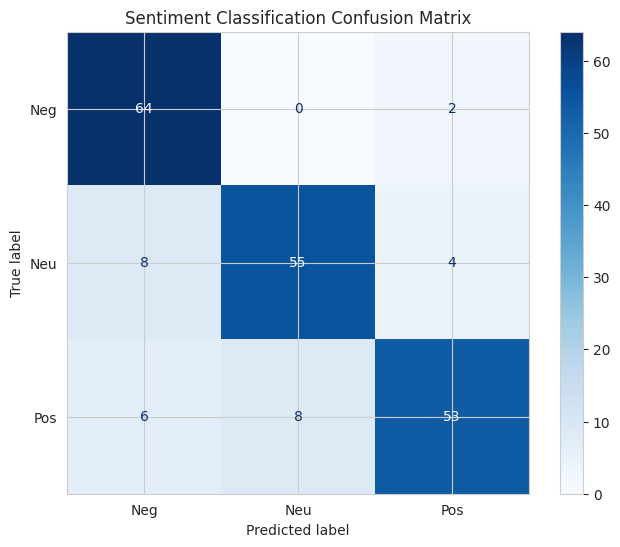


Total Failures: 28 out of 200


In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize storage for metrics
y_true = []
y_pred = []
incorrect_examples = []

print(f"{'Text':<70} | {'Expected':<10} | {'Predicted':<10} | {'Status'}")
print("-" * 110)

label_map = {0: "negative", 1: "neutral", 2: "positive"}

# 2. Run Inference
for row in ds_test:
    text = row['text']
    expected_label = row['label']
    expected_str = label_map[expected_label]
    
    # Preprocess and Predict
    lower_text = clean_and_normalize(text)
    predicted_str = predict(lower_text).lower()
    
    # Reverse map prediction to ID for confusion matrix
    inv_label_map = {"negative": 0, "neutral": 1, "positive": 2}
    predicted_label = inv_label_map[predicted_str]
    
    # Store for matrix
    y_true.append(expected_label)
    y_pred.append(predicted_label)
    
    status = "✅" if predicted_str == expected_str else "❌"
    
    # Only print and store if it was a failure
    if status == "❌":
        incorrect_examples.append({
            'text': text,
            'expected': expected_str,
            'predicted': predicted_str
        })
        print(f"{text[:68]:<70} | {expected_str:<10} | {predicted_str:<10} | {status}")

# --- 3. Confusion Matrix Visualization ---
print("\n" + "="*30)
print("CONFUSION MATRIX")
print("="*30)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neg', 'Neu', 'Pos'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Sentiment Classification Confusion Matrix")
plt.show()

# --- 4. Summary of Failures ---
print(f"\nTotal Failures: {len(incorrect_examples)} out of {len(ds_test)}")